<a href="https://colab.research.google.com/github/fathanzys/2DGames-FlappyBird/blob/adit/0102522024_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1. Import Library**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Menonaktifkan peringatan yang tidak krusial
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Memuat semua dataset dari file CSV
print("Memuat dataset...")
demographic_data = pd.read_csv("demographic.csv", encoding="latin1")
diet_data = pd.read_csv("diet.csv", encoding="latin1")
examination_data = pd.read_csv("examination.csv", encoding="latin1")
labs_data = pd.read_csv("labs.csv", encoding="latin1")
medications_data = pd.read_csv("medications.csv", encoding="latin1")
questionnaire_data = pd.read_csv("questionnaire.csv", encoding="latin1")

print("Semua dataset berhasil dimuat.")

# Menampilkan 5 baris pertama dari setiap dataset untuk inspeksi awal
print("\n--- Data Demografi (5 baris pertama) ---")
print(demographic_data.head())

print("\n--- Data Diet (5 baris pertama) ---")
print(diet_data.head())

print("\n--- Data Pemeriksaan (5 baris pertama) ---")
print(examination_data.head())

print("\n--- Data Laboratorium (5 baris pertama) ---")
print(labs_data.head())

print("\n--- Data Obat-obatan (5 baris pertama) ---")
print(medications_data.head())

print("\n--- Data Kuesioner (5 baris pertama) ---")
print(questionnaire_data.head())

Memuat dataset...
Semua dataset berhasil dimuat.

--- Data Demografi (5 baris pertama) ---
    SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  73557         8         2         1        69       NaN         4   
1  73558         8         2         1        54       NaN         3   
2  73559         8         2         1        72       NaN         3   
3  73560         8         2         1         9       NaN         3   
4  73561         8         2         2        73       NaN         3   

   RIDRETH3  RIDEXMON  RIDEXAGM  ...  DMDHREDU  DMDHRMAR  DMDHSEDU  \
0         4       1.0       NaN  ...       3.0       4.0       NaN   
1         3       1.0       NaN  ...       3.0       1.0       1.0   
2         3       2.0       NaN  ...       4.0       1.0       3.0   
3         3       1.0     119.0  ...       3.0       1.0       4.0   
4         3       1.0       NaN  ...       5.0       1.0       5.0   

       WTINT2YR      WTMEC2YR  SDMVPSU  SDMVSTRA  INDHH

In [47]:
# Membuat salinan dari data demografi sebagai dasar
merged_data = demographic_data.copy()

# Menggabungkan dataset lain secara berurutan menggunakan 'left' join
merged_data = merged_data.merge(examination_data, on='SEQN', how='left')
merged_data = merged_data.merge(labs_data, on='SEQN', how='left')
merged_data = merged_data.merge(medications_data, on='SEQN', how='left')
merged_data = merged_data.merge(questionnaire_data, on='SEQN', how='left')
merged_data = merged_data.merge(diet_data, on='SEQN', how='left')

print("Semua dataset telah digabungkan.")
print(f"Ukuran data gabungan: {merged_data.shape}")

# Memilih fitur-fitur spesifik untuk analisis
selected_features = ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1',
                     'DR1TSUGR', 'DR1TCARB',
                     'BMXBMI', 'BMXWAIST',
                     'LBDSGLSI', 'LBXGH', 'LBXIN',
                     'RXDUSE', 'RXDDRUG', 'RXDCOUNT',
                     'DIQ010'] # DIQ010 adalah kolom target (pernah didiagnosis diabetes)

# Membuat dataframe baru yang hanya berisi fitur terpilih
new_data = merged_data[selected_features].copy()

# Memeriksa jumlah nilai kosong (null) pada data yang baru diseleksi
print("\nJumlah nilai kosong pada fitur yang dipilih:")
print(new_data.isnull().sum())

Semua dataset telah digabungkan.
Ukuran data gabungan: (20194, 1824)

Jumlah nilai kosong pada fitur yang dipilih:
SEQN            0
RIDAGEYR        0
RIAGENDR        0
RIDRETH1        0
DR1TSUGR     2975
DR1TCARB     2975
BMXBMI       1672
BMXWAIST     2746
LBDSGLSI     4677
LBXGH        4442
LBXIN       13030
RXDUSE          0
RXDDRUG      6094
RXDCOUNT     6094
DIQ010        423
dtype: int64


In [48]:
# Menghapus kolom 'LBXIN' karena terlalu banyak nilai kosong
new_data = new_data.drop(columns=['LBXIN'])

# Mengisi nilai kosong pada kolom nama obat dengan 'Unknown'
new_data['RXDDRUG'] = new_data['RXDDRUG'].fillna('Unknown')

# Daftar kolom numerik yang akan diisi dengan median
columns_to_fill_median = [
    'RXDCOUNT', 'LBDSGLSI', 'LBXGH', 'DR1TSUGR',
    'DR1TCARB', 'BMXWAIST', 'BMXBMI'
]

# Mengisi nilai kosong dengan median untuk setiap kolom
for column in columns_to_fill_median:
    median_value = new_data[column].median()
    new_data[column] = new_data[column].fillna(median_value)

# Menghapus baris dimana status diabetes (DIQ010) tidak diketahui
new_data = new_data.dropna(subset=['DIQ010'])

# Memastikan hanya nilai 1 (Ya) dan 2 (Tidak) yang ada di kolom target
new_data = new_data[new_data['DIQ010'].isin([1.0, 2.0])]

# Mengubah kolom target menjadi format biner (1 = Ya, 0 = Tidak)
new_data['DIQ010'] = new_data['DIQ010'].map({1.0: 1, 2.0: 0})

print("Pembersihan data selesai.")
print("\nJumlah nilai kosong setelah pembersihan:")
print(new_data.isnull().sum())

Pembersihan data selesai.

Jumlah nilai kosong setelah pembersihan:
SEQN        0
RIDAGEYR    0
RIAGENDR    0
RIDRETH1    0
DR1TSUGR    0
DR1TCARB    0
BMXBMI      0
BMXWAIST    0
LBDSGLSI    0
LBXGH       0
RXDUSE      0
RXDDRUG     0
RXDCOUNT    0
DIQ010      0
dtype: int64


In [49]:
# Fungsi untuk membuat kategori BMI
def create_bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'NormalWeight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    elif 30 <= bmi < 35:
        return 'Obesity_Class_I'
    elif 35 <= bmi < 40:
        return 'Obesity_Class_II'
    else:
        return 'Obesity_Class_III'

# Terapkan fungsi ke kolom BMXBMI
new_data['BMICategory'] = new_data['BMXBMI'].apply(create_bmi_category)

# Fungsi untuk membuat grup usia
def create_age_group(age):
    if age <= 17:
        return 'Child_Adolescent'
    elif 18 <= age <= 34:
        return 'YoungAdult'
    elif 35 <= age <= 49:
        return 'MiddleAged_1'
    elif 50 <= age <= 64:
        return 'MiddleAged_2'
    elif 65 <= age <= 79:
        return 'SeniorAdult'
    else: # age >= 80
        return 'Elderly'

# Terapkan fungsi ke kolom RIDAGEYR
new_data['AgeGroup'] = new_data['RIDAGEYR'].apply(create_age_group)

# Membuat fitur biner untuk risiko glukosa berdasarkan nilai lab
new_data['Glucose_Prediabetic_Risk'] = ((new_data['LBDSGLSI'] >= 100) & (new_data['LBDSGLSI'] < 126)).astype(int)
new_data['Glucose_Diabetic_Level'] = (new_data['LBDSGLSI'] >= 126).astype(int)

# Membuat fitur biner untuk risiko HbA1c berdasarkan nilai lab
new_data['HbA1c_Prediabetic_Risk'] = ((new_data['LBXGH'] >= 5.7) & (new_data['LBXGH'] < 6.5)).astype(int)
new_data['HbA1c_Diabetic_Level'] = (new_data['LBXGH'] >= 6.5).astype(int)

print("Fitur-fitur baru telah berhasil dibuat.")

# Menampilkan contoh hasil pembuatan fitur baru
print("\nContoh data dengan fitur-fitur baru:")
print(new_data[['RIDAGEYR', 'AgeGroup', 'BMXBMI', 'BMICategory', 'LBDSGLSI', 'Glucose_Diabetic_Level']].head())

Fitur-fitur baru telah berhasil dibuat.

Contoh data dengan fitur-fitur baru:
   RIDAGEYR      AgeGroup  BMXBMI BMICategory  LBDSGLSI  \
0        69   SeniorAdult    26.7  Overweight     30.75   
1        69   SeniorAdult    26.7  Overweight     30.75   
2        54  MiddleAged_2    28.6  Overweight     12.16   
3        54  MiddleAged_2    28.6  Overweight     12.16   
4        54  MiddleAged_2    28.6  Overweight     12.16   

   Glucose_Diabetic_Level  
0                       0  
1                       0  
2                       0  
3                       0  
4                       0  


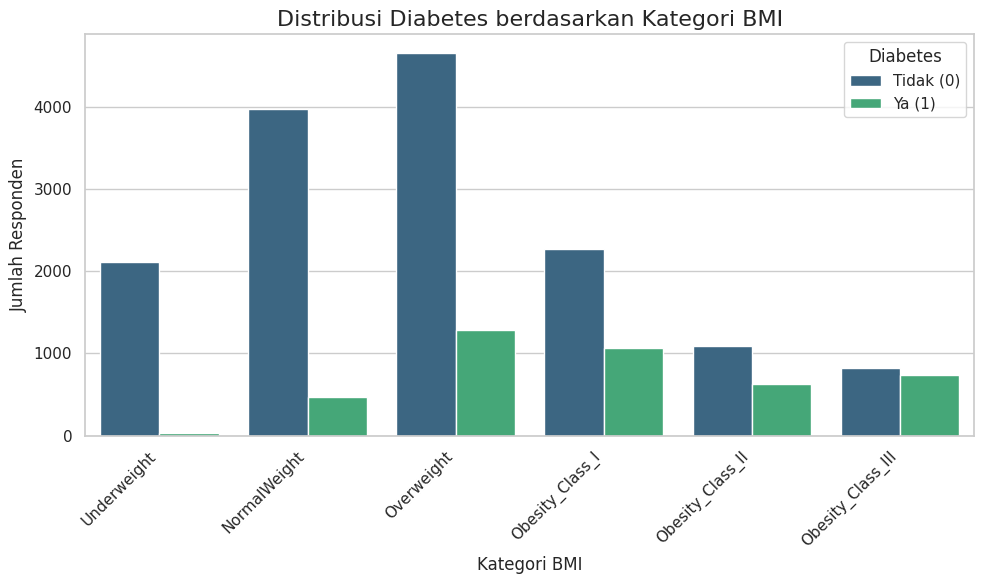

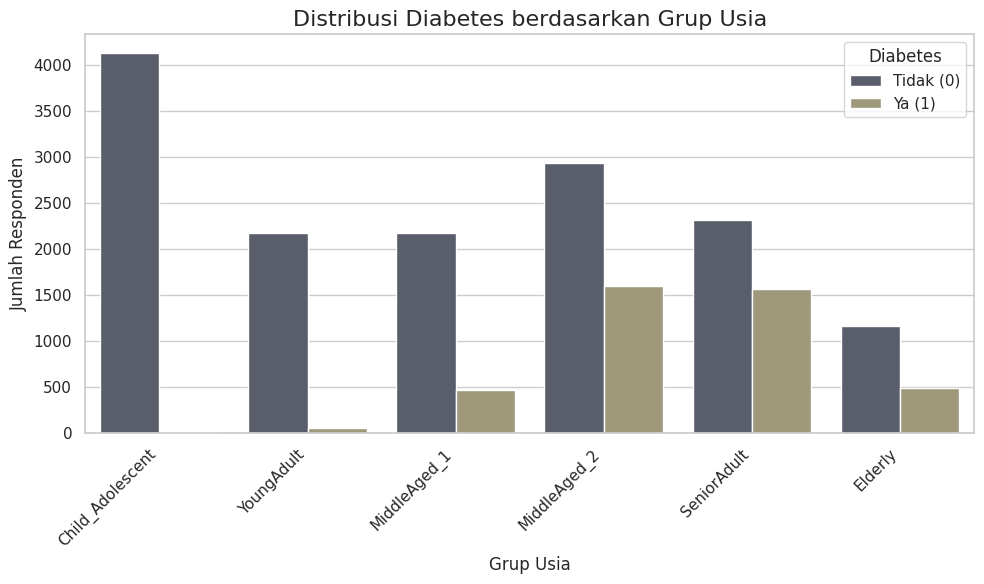

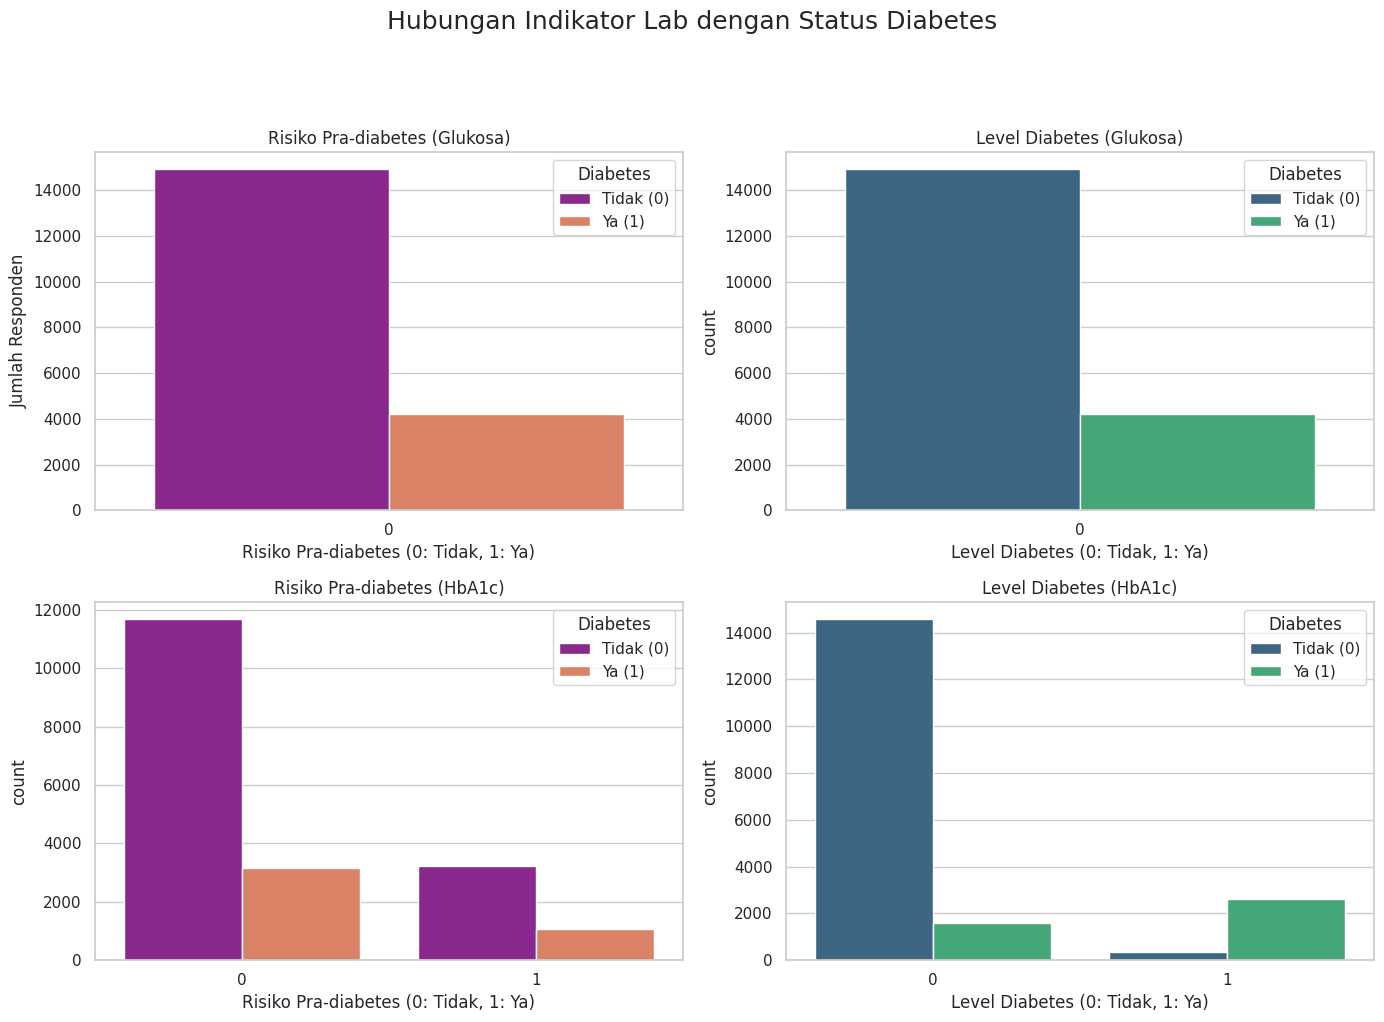

In [50]:
# 1. Visualisasi Distribusi Diabetes berdasarkan Kategori BMI
plt.figure(figsize=(10, 6))
sns.countplot(data=new_data, x='BMICategory', hue='DIQ010', palette='viridis',
              order=['Underweight', 'NormalWeight', 'Overweight', 'Obesity_Class_I', 'Obesity_Class_II', 'Obesity_Class_III'])
plt.title('Distribusi Diabetes berdasarkan Kategori BMI', fontsize=16)
plt.xlabel('Kategori BMI')
plt.ylabel('Jumlah Responden')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Diabetes', labels=['Tidak (0)', 'Ya (1)'])
plt.tight_layout()
plt.show()

# 2. Visualisasi Distribusi Diabetes berdasarkan Grup Usia
plt.figure(figsize=(10, 6))
sns.countplot(data=new_data, x='AgeGroup', hue='DIQ010', palette='cividis',
              order=['Child_Adolescent', 'YoungAdult', 'MiddleAged_1', 'MiddleAged_2', 'SeniorAdult', 'Elderly'])
plt.title('Distribusi Diabetes berdasarkan Grup Usia', fontsize=16)
plt.xlabel('Grup Usia')
plt.ylabel('Jumlah Responden')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Diabetes', labels=['Tidak (0)', 'Ya (1)'])
plt.tight_layout()
plt.show()

# 3. Visualisasi Hubungan Indikator Lab dengan Status Diabetes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('Hubungan Indikator Lab dengan Status Diabetes', y=1.02, fontsize=18)

# Glukosa Pra-diabetes
sns.countplot(data=new_data, x='Glucose_Prediabetic_Risk', hue='DIQ010', palette='plasma', ax=axes[0, 0])
axes[0, 0].set_title('Risiko Pra-diabetes (Glukosa)')
axes[0, 0].set_xlabel('Risiko Pra-diabetes (0: Tidak, 1: Ya)')
axes[0, 0].set_ylabel('Jumlah Responden')
axes[0, 0].legend(title='Diabetes', labels=['Tidak (0)', 'Ya (1)'])

# Glukosa Diabetes
sns.countplot(data=new_data, x='Glucose_Diabetic_Level', hue='DIQ010', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Level Diabetes (Glukosa)')
axes[0, 1].set_xlabel('Level Diabetes (0: Tidak, 1: Ya)')
axes[0, 1].legend(title='Diabetes', labels=['Tidak (0)', 'Ya (1)'])

# HbA1c Pra-diabetes
sns.countplot(data=new_data, x='HbA1c_Prediabetic_Risk', hue='DIQ010', palette='plasma', ax=axes[1, 0])
axes[1, 0].set_title('Risiko Pra-diabetes (HbA1c)')
axes[1, 0].set_xlabel('Risiko Pra-diabetes (0: Tidak, 1: Ya)')
axes[1, 0].legend(title='Diabetes', labels=['Tidak (0)', 'Ya (1)'])

# HbA1c Diabetes
sns.countplot(data=new_data, x='HbA1c_Diabetic_Level', hue='DIQ010', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Level Diabetes (HbA1c)')
axes[1, 1].set_xlabel('Level Diabetes (0: Tidak, 1: Ya)')
axes[1, 1].legend(title='Diabetes', labels=['Tidak (0)', 'Ya (1)'])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [51]:
# Menerapkan one-hot encoding ke variabel-variabel kategorikal
new_data = pd.get_dummies(new_data,
                          columns=['RIAGENDR', 'RIDRETH1', 'RXDDRUG', 'BMICategory', 'AgeGroup'],
                          drop_first=True) # drop_first=True untuk menghindari multikolinearitas

print("\nInfo DataFrame Setelah One-Hot Encoding:")
new_data.info()

print("\nContoh 5 baris pertama setelah One-Hot Encoding:")
print(new_data.head())


Info DataFrame Setelah One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 19126 entries, 0 to 20193
Columns: 713 entries, SEQN to AgeGroup_YoungAdult
dtypes: bool(698), float64(7), int64(8)
memory usage: 15.1 MB

Contoh 5 baris pertama setelah One-Hot Encoding:
    SEQN  RIDAGEYR  DR1TSUGR  DR1TCARB  BMXBMI  BMXWAIST  LBDSGLSI  LBXGH  \
0  73557        69    176.47    239.59    26.7     100.0     30.75   13.9   
1  73557        69    176.47    239.59    26.7     100.0     30.75   13.9   
2  73558        54     44.99    423.78    28.6     107.6     12.16    9.1   
3  73558        54     44.99    423.78    28.6     107.6     12.16    9.1   
4  73558        54     44.99    423.78    28.6     107.6     12.16    9.1   

   RXDUSE  RXDCOUNT  ...  BMICategory_Obesity_Class_I  \
0       1       2.0  ...                        False   
1       1       2.0  ...                        False   
2       1       4.0  ...                        False   
3       1       4.0  ...          

In [52]:
# Fungsi untuk membatasi (cap) outliers menggunakan IQR
def cap_outliers_iqr(new_data_column):
    Q1 = new_data_column.quantile(0.25)
    Q3 = new_data_column.quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    return new_data_column.clip(lower=lower_bound, upper=upper_bound)

# Memilih kolom numerik yang akan ditangani outlier-nya
numeric_cols = new_data.select_dtypes(include=np.number).columns.tolist()

# Kolom yang dikecualikan dari proses capping (ID, target, dan kolom hasil one-hot)
numeric_cols_to_exclude_from_capping = ['SEQN', 'DIQ010'] + [col for col in new_data.columns if col.startswith(('RIAGENDR_', 'RIDRETH1_', 'RXDDRUG_'))]
cols_to_cap = [col for col in numeric_cols if col not in numeric_cols_to_exclude_from_capping]

print(f"\nKolom yang akan diterapkan penanganan outlier: {cols_to_cap}")

# Menerapkan fungsi capping ke setiap kolom yang relevan
for col in cols_to_cap:
    new_data[col] = cap_outliers_iqr(new_data[col])

print("\nPenanganan outlier selesai.")
print("\nStatistik deskriptif setelah outlier di-cap (contoh):")
print(new_data[cols_to_cap].describe())


Kolom yang akan diterapkan penanganan outlier: ['RIDAGEYR', 'DR1TSUGR', 'DR1TCARB', 'BMXBMI', 'BMXWAIST', 'LBDSGLSI', 'LBXGH', 'RXDUSE', 'RXDCOUNT', 'Glucose_Prediabetic_Risk', 'Glucose_Diabetic_Level', 'HbA1c_Prediabetic_Risk', 'HbA1c_Diabetic_Level']

Penanganan outlier selesai.

Statistik deskriptif setelah outlier di-cap (contoh):
           RIDAGEYR      DR1TSUGR      DR1TCARB        BMXBMI      BMXWAIST  \
count  19126.000000  19126.000000  19126.000000  19126.000000  19126.000000   
mean      45.876503     98.332521    227.922492     28.023384     95.990181   
std       25.177544     52.882654     92.588867      7.643347     20.961048   
min        1.000000      0.130000      8.670000     12.100000     48.750000   
25%       22.000000     61.122500    166.640000     22.900000     84.300000   
50%       52.000000     88.860000    213.750000     27.500000     97.500000   
75%       67.000000    124.535000    275.897500     32.400000    108.000000   
max       80.000000    219.653

In [53]:
# Memilih kolom yang akan di-scale (semua yang di-cap kecuali ID dan target)
cols_to_scale = [col for col in cols_to_cap if col != 'DIQ010' and col != 'SEQN']

# Membuat dan menerapkan StandardScaler
scaler = StandardScaler()
new_data[cols_to_scale] = scaler.fit_transform(new_data[cols_to_scale])

print("\nPenskalaan fitur selesai.")
print("\nContoh 5 baris pertama setelah penskalaan:")
print(new_data[cols_to_scale].head())


Penskalaan fitur selesai.

Contoh 5 baris pertama setelah penskalaan:
   RIDAGEYR  DR1TSUGR  DR1TCARB    BMXBMI  BMXWAIST  LBDSGLSI     LBXGH  \
0  0.918442  1.477602  0.126017 -0.173147  0.191304  1.923856  1.995676   
1  0.918442  1.477602  0.126017 -0.173147  0.191304  1.923856  1.995676   
2  0.322657 -1.008722  2.115402  0.075442  0.553890  1.923856  1.995676   
3  0.322657 -1.008722  2.115402  0.075442  0.553890  1.923856  1.995676   
4  0.322657 -1.008722  2.115402  0.075442  0.553890  1.923856  1.995676   

     RXDUSE  RXDCOUNT  Glucose_Prediabetic_Risk  Glucose_Diabetic_Level  \
0 -0.650338 -1.269843                       0.0                     0.0   
1 -0.650338 -1.269843                       0.0                     0.0   
2 -0.650338 -0.538147                       0.0                     0.0   
3 -0.650338 -0.538147                       0.0                     0.0   
4 -0.650338 -0.538147                       0.0                     0.0   

   HbA1c_Prediabetic_Risk  

In [54]:
# Memisahkan fitur (X) dan target (y)
X = new_data.drop(columns=["SEQN", "DIQ010"])
y = new_data["DIQ010"]

# Memeriksa apakah ada nilai NaN di target dan menghapusnya jika ada
nan_in_y_indices = y[y.isna()].index
if len(nan_in_y_indices) > 0:
    print(f"Peringatan: {len(nan_in_y_indices)} nilai kosong ditemukan di variabel target 'y'.")
    print("Baris ini sedang dihapus dari X dan y...")
    X = X.drop(nan_in_y_indices)
    y = y.drop(nan_in_y_indices)
    print("Nilai kosong telah dihapus.")
else:
    print("Tidak ada nilai kosong di variabel target 'y'.")

# Membagi data menjadi data latih dan data uji
# stratify=y memastikan proporsi target sama di kedua set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nUkuran Set Latih (X_train): {X_train.shape}")
print(f"Ukuran Set Uji (X_test): {X_test.shape}")
print(f"\nDistribusi Target di Set Latih:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribusi Target di Set Uji:\n{y_test.value_counts(normalize=True)}")

Tidak ada nilai kosong di variabel target 'y'.

Ukuran Set Latih (X_train): (15300, 711)
Ukuran Set Uji (X_test): (3826, 711)

Distribusi Target di Set Latih:
DIQ010
0    0.779542
1    0.220458
Name: proportion, dtype: float64

Distribusi Target di Set Uji:
DIQ010
0    0.779404
1    0.220596
Name: proportion, dtype: float64


In [55]:
# Mendefinisikan model-model yang akan digunakan
models = {
    "Logistic Regression" : LogisticRegression(random_state=42, solver="liblinear"),
    "Random Forest Classifier" : RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost" : XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Dictionary untuk menyimpan hasil
results = {}

print("\n--- Memulai Pelatihan dan Evaluasi Model ---\n")

# Melakukan iterasi untuk setiap model
for name, model in models.items():
    print(f"--- Melatih Model: {name} ---")

    # Melatih model
    model.fit(X_train, y_train)

    # Membuat prediksi
    y_predict = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Menyimpan metrik evaluasi
    results[name] = {
        "Accuracy" : accuracy_score(y_test, y_predict),
        "Precision" : precision_score(y_test, y_predict),
        "Recall" : recall_score(y_test, y_predict),
        "F1-Score" : f1_score(y_test, y_predict),
        "ROC-AUC" : roc_auc_score(y_test, y_proba),
        "Confusion Matrix" : confusion_matrix(y_test, y_predict)
    }

    # Menampilkan laporan klasifikasi
    print(f"Laporan Klasifikasi untuk {name}:\n{classification_report(y_test, y_predict)}\n")


--- Memulai Pelatihan dan Evaluasi Model ---

--- Melatih Model: Logistic Regression ---
Laporan Klasifikasi untuk Logistic Regression:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2982
           1       0.87      0.73      0.79       844

    accuracy                           0.92      3826
   macro avg       0.90      0.85      0.87      3826
weighted avg       0.91      0.92      0.91      3826


--- Melatih Model: Random Forest Classifier ---
Laporan Klasifikasi untuk Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2982
           1       0.99      0.94      0.97       844

    accuracy                           0.99      3826
   macro avg       0.99      0.97      0.98      3826
weighted avg       0.99      0.99      0.99      3826


--- Melatih Model: XGBoost ---


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:24:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Laporan Klasifikasi untuk XGBoost:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2982
           1       0.99      0.96      0.97       844

    accuracy                           0.99      3826
   macro avg       0.99      0.98      0.98      3826
weighted avg       0.99      0.99      0.99      3826




In [56]:
# Membuat DataFrame dari hasil evaluasi
results_df = pd.DataFrame(results).T.drop(columns='Confusion Matrix')
print("--- Ringkasan Performa Model ---")
print(results_df)

--- Ringkasan Performa Model ---
                          Accuracy Precision    Recall  F1-Score   ROC-AUC
Logistic Regression       0.915839  0.865546  0.732227  0.793325  0.950261
Random Forest Classifier  0.985625  0.992509  0.941943  0.966565  0.994159
XGBoost                   0.988761  0.989011  0.959716  0.974143  0.990183


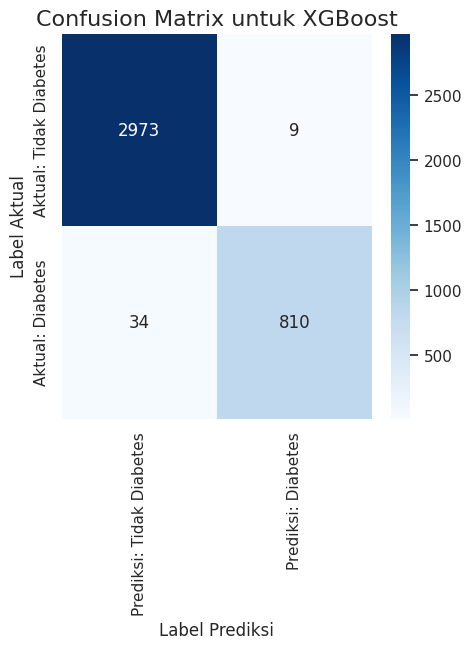


Analisis Selesai!


In [64]:
# Mengambil confusion matrix dari model terbaik (XGBoost)
best_model_name = "XGBoost"
cmatrix = results[best_model_name]["Confusion Matrix"]

# Visualisasi heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(cmatrix, annot=True, fmt='d', cmap="Blues",
           xticklabels=["Prediksi: Tidak Diabetes", "Prediksi: Diabetes"],
           yticklabels=["Aktual: Tidak Diabetes", "Aktual: Diabetes"])
plt.title(f"Confusion Matrix untuk {best_model_name}", fontsize=16)
plt.xlabel("Label Prediksi")
plt.ylabel("Label Aktual")
plt.show()

print("\nAnalisis Selesai!")